This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [0]:
!pip install keras keras-hub --upgrade -q

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [0]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## A deep dive on Keras

### A spectrum of workflows

### Different ways to build Keras models

#### The Sequential model

In [2]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [3]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

In [4]:
model.weights

[]

In [5]:
model.build(input_shape=(None, 3))
model.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-0.06040816 -0.08504792 -0.15866911 -0.02354993 -0.11132289 -0.05839687
   -0.16288283 -0.11244726  0.05658001 -0.22260833  0.25739813 -0.2271379
   -0.22550169 -0.00940338  0.02457512  0.28064027 -0.0767049  -0.03819634
    0.01087991 -0.09503927 -0.1828629   0.07120809 -0.19788687  0.23141353
   -0.00899648  0.01149307  0.05733387  0.19232285  0.04505077 -0.03154455
    0.21036704  0.28235668  0.20710003  0.17360699 -0.20452747 -0.13817193
   -0.07093354 -0.04527358 -0.14193508  0.15761817  0.10007347 -0.2434699
    0.29190174 -0.1954271  -0.05390805 -0.15297195 -0.16730851 -0.11933549
    0.27363616 -0.21770298 -0.07640938  0.15078609 -0.01017229  0.11893523
    0.18920688 -0.06090438  0.13707718  0.16012682 -0.02174263 -0.24767047
    0.04949278 -0.29178596  0.09922051  0.2016264 ]
  [ 0.08294224 -0.00538088  0.15119454  0.25625643 -0.00855663 -0.17231959
   -0.11581258 -0.26141754 -0.0630393  -0.164

In [6]:
model.summary(line_length=80)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                   │ (None, 64)               │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_3 (Dense)                   │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary(line_length=80)

In [0]:
model = keras.Sequential()
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

In [0]:
model.summary(line_length=80)

In [0]:
model.add(layers.Dense(10, activation="softmax"))
model.summary(line_length=80)

#### The Functional API

##### A simple example

In [0]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [0]:
inputs = keras.Input(shape=(3,), name="my_input")

In [0]:
inputs.shape

In [0]:
inputs.dtype

In [0]:
features = layers.Dense(64, activation="relu")(inputs)

In [0]:
features.shape

In [0]:
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [0]:
model.summary(line_length=80)

##### Multi-input, multi-output models

In [7]:
vocabulary_size = 10000
num_tags = 100
num_departments = 4

title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

features = layers.Concatenate()([title, text_body, tags])
features = layers.Dense(64, activation="relu", name="dense_features")(features)

priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department"
)(features)

model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department],
)

##### Training a multi-input, multi-output model

In [8]:
import numpy as np

num_samples = 1280

title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, num_departments, size=(num_samples, 1))

model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    [title_data, text_body_data, tags_data], [priority_data, department_data]
)
priority_preds, department_preds = model.predict(
    [title_data, text_body_data, tags_data]
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - department_accuracy: 0.2531 - department_loss: 11.7225 - loss: 12.0583 - priority_loss: 0.3358 - priority_mean_absolute_error: 0.5004
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - department_accuracy: 0.2586 - department_loss: 11.9501 - loss: 12.2999 - priority_loss: 0.3498 - priority_mean_absolute_error: 0.5151 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step


In [9]:
model.compile(
    optimizer="adam",
    loss={
        "priority": "mean_squared_error",
        "department": "sparse_categorical_crossentropy",
    },
    metrics={
        "priority": ["mean_absolute_error"],
        "department": ["accuracy"],
    },
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - department_accuracy: 0.2586 - department_loss: 11.9501 - loss: 12.2999 - priority_loss: 0.3498 - priority_mean_absolute_error: 0.5151
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - department_accuracy: 0.2586 - department_loss: 11.9501 - loss: 12.2999 - priority_loss: 0.3498 - priority_mean_absolute_error: 0.5151 
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step


##### The power of the Functional API: Access to layer connectivity

###### Plotting layer connectivity

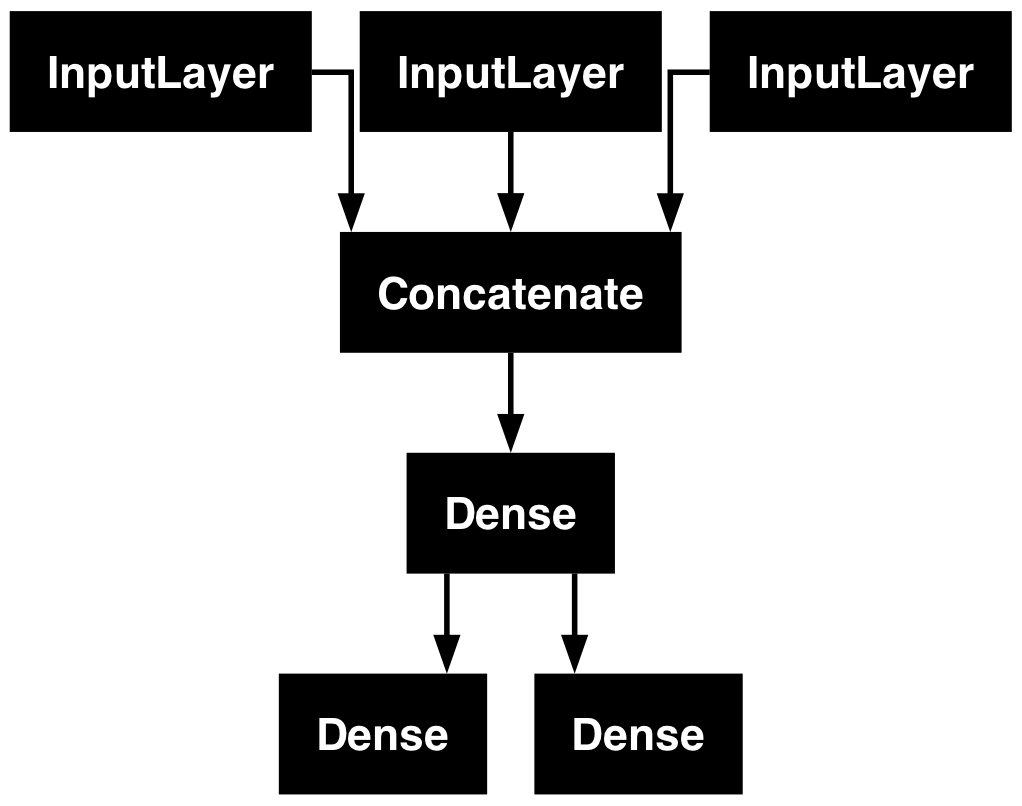

In [10]:
keras.utils.plot_model(model, "ticket_classifier.png")

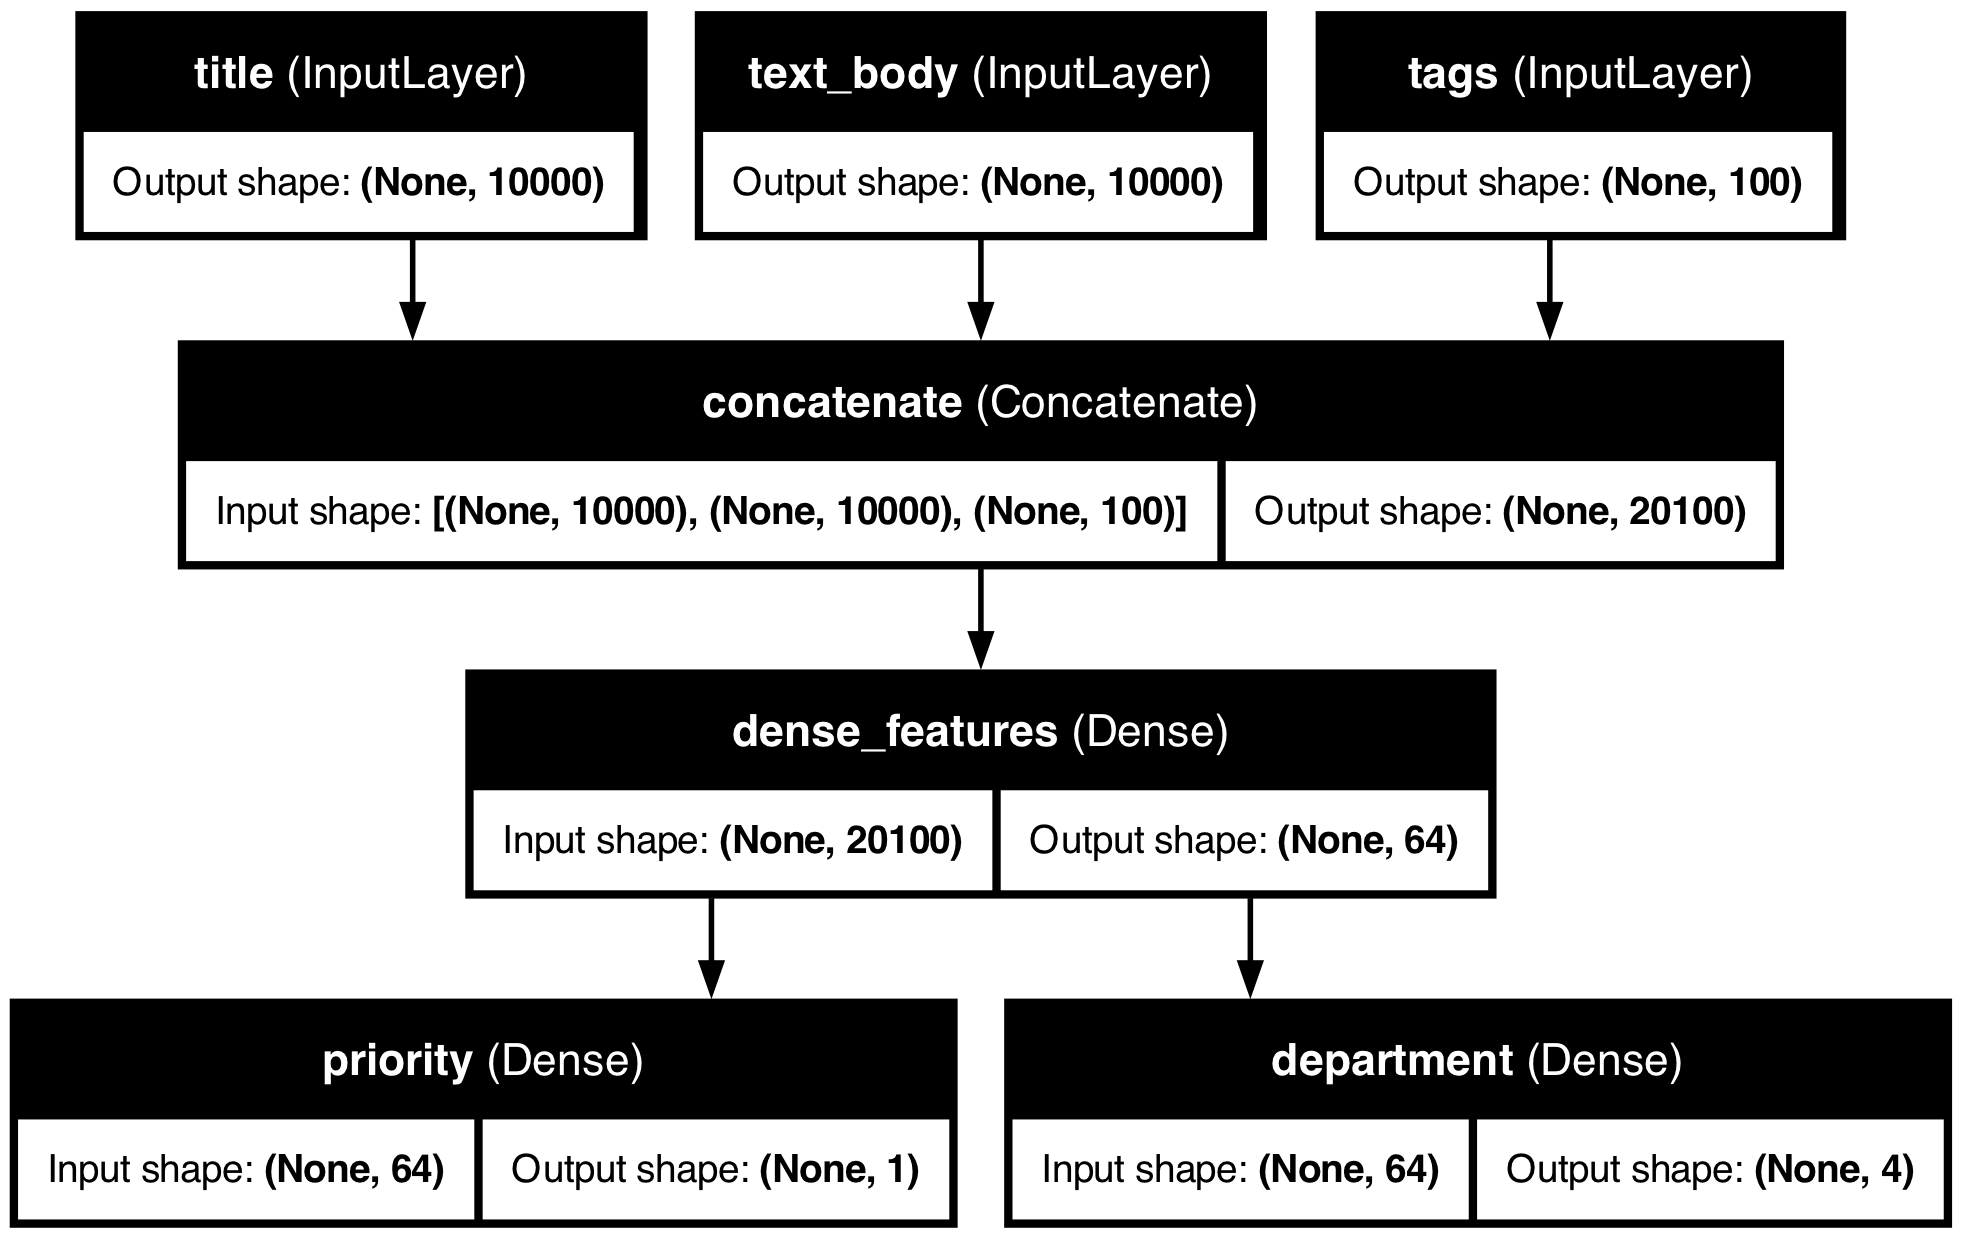

In [11]:
keras.utils.plot_model(
    model,
    "ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True,
)

###### Feature extraction with a Functional model

In [12]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_features, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [13]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [14]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>

In [0]:
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags], outputs=[priority, department, difficulty]
)

In [0]:
keras.utils.plot_model(
    new_model,
    "updated_ticket_classifier.png",
    show_shapes=True,
    show_layer_names=True,
)

#### Subclassing the Model class

##### Rewriting our previous example as a subclassed model

In [0]:
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        super().__init__()
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax"
        )

    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)
        return priority, department

In [0]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

In [0]:
model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)
model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
    epochs=1,
)
model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
)
priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

##### Beware: What subclassed models don't support

#### Mixing and matching different components

In [0]:
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sigmoid"
        else:
            num_units = num_classes
            activation = "softmax"
        self.dense = layers.Dense(num_units, activation=activation)

    def call(self, inputs):
        return self.dense(inputs)

inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [0]:
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifier = binary_classifier

    def call(self, inputs):
        features = self.dense(inputs)
        return self.classifier(features)

model = MyModel()

#### Remember: Use the right tool for the job

### Using built-in training and evaluation loops

In [3]:
from keras.datasets import mnist

def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)
    return model

(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)
predictions = model.predict(test_images)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9123 - loss: 0.2906 - val_accuracy: 0.9623 - val_loss: 0.1309
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step - accuracy: 0.9570 - loss: 0.1448 - val_accuracy: 0.9688 - val_loss: 0.1043
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.9638 - loss: 0.1129 - val_accuracy: 0.9720 - val_loss: 0.0922
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step - accuracy: 0.9740 - loss: 0.0853
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 260us/step


#### Writing your own metrics

In [0]:
from keras import ops

class RootMeanSquaredError(keras.metrics.Metric):
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.one_hot(y_true, num_classes=ops.shape(y_pred)[1])
        mse = ops.sum(ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = ops.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)

    def result(self):
        return ops.sqrt(self.mse_sum / self.total_samples)

    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0.)

In [0]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)
test_metrics = model.evaluate(test_images, test_labels)

#### Using callbacks

##### The EarlyStopping and ModelCheckpoint callbacks

In [4]:
callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="accuracy",
        patience=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoint_path.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9154 - loss: 0.2854 - val_accuracy: 0.9577 - val_loss: 0.1435
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step - accuracy: 0.9558 - loss: 0.1458 - val_accuracy: 0.9707 - val_loss: 0.1013
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - accuracy: 0.9643 - loss: 0.1141 - val_accuracy: 0.9757 - val_loss: 0.0847
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.9704 - loss: 0.0943 - val_accuracy: 0.9747 - val_loss: 0.0832
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - accuracy: 0.9743 - loss: 0.0821 - val_accuracy: 0.9745 - val_loss: 0.0855
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - accuracy: 0.9751 - loss: 0.0755 - val_accuracy: 0.9782 - val_loss: 0.0740
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step - accuracy: 0.9788 - loss: 0.0667 - val_accuracy: 0.9787 - val_loss: 0.0770
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step - accuracy: 0.9794 - l

In [17]:
model = keras.models.load_model("checkpoint_path.keras")

#### Writing your own callbacks

In [0]:
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []

    def on_batch_end(self, batch, logs):
        self.per_batch_losses.append(logs.get("loss"))

    def on_epoch_end(self, epoch, logs):
        plt.clf()
        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )
        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}", dpi=300)
        self.per_batch_losses = []

In [0]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=[LossHistory()],
    validation_data=(val_images, val_labels),
)

#### Monitoring and visualization with TensorBoard

In [5]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

tensorboard = keras.callbacks.TensorBoard(
    log_dir="./logs",
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels),
    callbacks=[tensorboard],
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9135 - loss: 0.2931 - val_accuracy: 0.9625 - val_loss: 0.1347
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9545 - loss: 0.1477 - val_accuracy: 0.9686 - val_loss: 0.1059
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 996us/step - accuracy: 0.9640 - loss: 0.1161 - val_accuracy: 0.9728 - val_loss: 0.0866
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 995us/step - accuracy: 0.9713 - loss: 0.0952 - val_accuracy: 0.9759 - val_loss: 0.0847
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 998us/step - accuracy: 0.9727 - loss: 0.0857 - val_accuracy: 0.9781 - val_loss: 0.0743
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 999us/step - accuracy: 0.9754 - loss: 0.0741 - val_accuracy: 0.9788 - val_loss: 0.0739
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 998us/step - accuracy: 0.9773 - loss: 0.0695 - val_accuracy: 0.9797 - val_loss: 0.0698
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1000us/step - accuracy: 0.9800 - lo

Instead of this, in local usage, just do
```bash
uv run tensorboard --logdir=./logs
``` 

In [ ]:
%load_ext tensorboard
%tensorboard --logdir ./logs

### Writing your own training and evaluation loops

#### Training vs. inference

#### Writing custom training step functions

##### A TensorFlow training step function

In [0]:
%%backend tensorflow
import tensorflow as tf

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs, training=True)
        loss = loss_fn(targets, predictions)
    gradients = tape.gradient(loss, model.trainable_weights)
    optimizer.apply(gradients, model.trainable_weights)
    return loss

In [0]:
%%backend tensorflow
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

##### A PyTorch training step function

In [0]:
%%backend torch
import torch

model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam()

def train_step(inputs, targets):
    predictions = model(inputs, training=True)
    loss = loss_fn(targets, predictions)
    loss.backward()
    gradients = [weight.value.grad for weight in model.trainable_weights]
    with torch.no_grad():
        optimizer.apply(gradients, model.trainable_weights)
    model.zero_grad()
    return loss

In [0]:
%%backend torch
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]
loss = train_step(inputs, targets)

##### A JAX training step function

In [0]:
%%backend jax
model = get_mnist_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy()

def compute_loss_and_updates(
    trainable_variables, non_trainable_variables, inputs, targets
):
    outputs, non_trainable_variables = model.stateless_call(
        trainable_variables, non_trainable_variables, inputs, training=True
    )
    loss = loss_fn(targets, outputs)
    return loss, non_trainable_variables

In [0]:
%%backend jax
import jax

grad_fn = jax.value_and_grad(compute_loss_and_updates, has_aux=True)

In [0]:
%%backend jax
optimizer = keras.optimizers.Adam()
optimizer.build(model.trainable_variables)

def train_step(state, inputs, targets):
    (trainable_variables, non_trainable_variables, optimizer_variables) = state
    (loss, non_trainable_variables), grads = grad_fn(
        trainable_variables, non_trainable_variables, inputs, targets
    )
    trainable_variables, optimizer_variables = optimizer.stateless_apply(
        optimizer_variables, grads, trainable_variables
    )
    return loss, (
        trainable_variables,
        non_trainable_variables,
        optimizer_variables,
    )

In [0]:
%%backend jax
batch_size = 32
inputs = train_images[:batch_size]
targets = train_labels[:batch_size]

trainable_variables = [v.value for v in model.trainable_variables]
non_trainable_variables = [v.value for v in model.non_trainable_variables]
optimizer_variables = [v.value for v in optimizer.variables]

state = (trainable_variables, non_trainable_variables, optimizer_variables)
loss, state = train_step(state, inputs, targets)

#### Low-level usage of metrics

In [0]:
from keras import ops

metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
metric.update_state(targets, predictions)
current_result = metric.result()
print(f"result: {current_result:.2f}")

In [0]:
values = ops.array([0, 1, 2, 3, 4])
mean_tracker = keras.metrics.Mean()
for value in values:
    mean_tracker.update_state(value)
print(f"Mean of values: {mean_tracker.result():.2f}")

In [0]:
metric = keras.metrics.SparseCategoricalAccuracy()
targets = ops.array([0, 1, 2])
predictions = ops.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])

metric_variables = metric.variables
metric_variables = metric.stateless_update_state(
    metric_variables, targets, predictions
)
current_result = metric.stateless_result(metric_variables)
print(f"result: {current_result:.2f}")

metric_variables = metric.stateless_reset_state()

#### Using fit() with a custom training loop

##### Customizing fit() with TensorFlow

In [0]:
%%backend tensorflow
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = loss_fn(targets, predictions)
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply(gradients, self.trainable_weights)

        loss_tracker.update_state(loss)
        return {"loss": loss_tracker.result()}

    @property
    def metrics(self):
        return [loss_tracker]

In [0]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [0]:
%%backend tensorflow
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

##### Customizing fit() with PyTorch

In [0]:
%%backend torch
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()
loss_tracker = keras.metrics.Mean(name="loss")

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)
        loss = loss_fn(targets, predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)

        loss_tracker.update_state(loss)
        return {"loss": loss_tracker.result()}

    @property
    def metrics(self):
        return [loss_tracker]

In [0]:
%%backend torch
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [0]:
%%backend torch
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

##### Customizing fit() with JAX

In [0]:
%%backend jax
import keras
from keras import layers

loss_fn = keras.losses.SparseCategoricalCrossentropy()

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = loss_fn(targets, predictions)
        return loss, non_trainable_variables

    def train_step(self, state, data):
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, non_trainable_variables), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )

        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        logs = {"loss": loss}
        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        )
        return logs, state

In [0]:
%%backend jax
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())
    return model

In [0]:
%%backend jax
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

#### Handling metrics in a custom train_step()

##### train_step() metrics handling with TensorFlow

In [0]:
%%backend tensorflow
import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape() as tape:
            predictions = self(inputs, training=True)
            loss = self.compute_loss(y=targets, y_pred=predictions)

        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply(gradients, self.trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

In [0]:
%%backend tensorflow
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

##### train_step() metrics handling with PyTorch

In [0]:
%%backend torch
import keras
from keras import layers

class CustomModel(keras.Model):
    def train_step(self, data):
        inputs, targets = data
        predictions = self(inputs, training=True)
        loss = self.compute_loss(y=targets, y_pred=predictions)

        loss.backward()
        trainable_weights = [v for v in self.trainable_weights]
        gradients = [v.value.grad for v in trainable_weights]

        with torch.no_grad():
            self.optimizer.apply(gradients, trainable_weights)

        for metric in self.metrics:
            if metric.name == "loss":
                metric.update_state(loss)
            else:
                metric.update_state(targets, predictions)

        return {m.name: m.result() for m in self.metrics}

In [0]:
%%backend torch
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

##### train_step() metrics handling with JAX

In [0]:
%%backend jax
import keras
from keras import layers

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = self.compute_loss(y=targets, y_pred=predictions)
        return loss, (predictions, non_trainable_variables)

    def train_step(self, state, data):
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        (loss, (predictions, non_trainable_variables)), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )
        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        new_metrics_vars = []
        logs = {}
        for metric in self.metrics:
            num_prev = len(new_metrics_vars)
            num_current = len(metric.variables)
            current_vars = metrics_variables[num_prev : num_prev + num_current]
            if metric.name == "loss":
                current_vars = metric.stateless_update_state(current_vars, loss)
            else:
                current_vars = metric.stateless_update_state(
                    current_vars, targets, predictions
                )
            logs[metric.name] = metric.stateless_result(current_vars)
            new_metrics_vars += current_vars

        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            new_metrics_vars,
        )
        return logs, state